In [ ]:
"""
As we start with two arbitrary weights, we cannot expect the result to be correct. For some points (fruits) it
may return the proper value, i.e. 1 for a lemon and 0 for an orange. In case we get the wrong result, we have to
correct our weight values. First we have to calculate the error. The error is the difference between the target or
expected value ( target_result ) and the calculated value ( calculated_result ). With this error
we have to adjust the weight values with an incremental value, i.e. w1 = w1 + Δw1 and w2 = w2 + Δw2

refer : error adjsuted weights.jpg

If the error e is 0, i.e. the target result is equal to the calculated result, we don't have to do anything. The
network is perfect for these input values. If the error is not equal, we have to change the weights. We have to
change the weights by adding small values to them. These values may be positive or negative. The amount we
have a change a weight value depends on the error and on the input value. Let us assume, x1 = 0 and x2 > 0.
In this case the result in this case solely results on the input x2. This on the other hand means that we can
minimize the error by changing solely w2. If the error is negative, we will have to add a negative value to it,
and if the error is positive, we will have to add a positive value to it. From this we can understand that
whatever the input values are, we can multiply them with the error and we get values, we can add to the
weights. One thing is still missing: Doing this we would learn to fast. We have many samples and each sample
should only change the weights a little bit. Therefore we have to multiply this result with a learning rate
( self.learning_rate ). The learning rate is used to control how fast the weights are updated. Small
values for the learning rate result in a long training process, larger values bear the risk of ending up in suboptimal
weight values. We will have a closer look at this in our chapter on backpropagation.

We are ready now to write the code for adapting the weights, which means training the network. For this
purpose, we add a method 'adjust' to our Perceptron class. The task of this method is to correct the error.
"""

In [1]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

def points_within_circle(radius, center=(0, 0), number_of_points=100):
    center_x, center_y = center
    r = radius * np.sqrt(np.random.random((number_of_points,)))
    theta = np.random.random((number_of_points,)) * 2 * np.pi
    # print('r', r)
    # print('theta', theta)
    x = center_x + r * np.cos(theta)  # use cosine to find x values
    y = center_y + r * np.sin(theta)  # use sine to find y values
    # print('x', x)
    # print('y', y)
    return x, y

oranges_x, oranges_y = points_within_circle(1.6, (5, 2), 100)
lemons_x, lemons_y = points_within_circle(1.9, (2, 5), 100)

oranges = list(zip(oranges_x, oranges_y))
lemons = list(zip(lemons_x, lemons_y))

# labelling oranges with 0 and lemons with 1:
labelled_data = list(zip(oranges + lemons, [0] * len(oranges) + [1] * len(lemons)))
random.shuffle(labelled_data)

data, labels = zip(*labelled_data)

res = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42)
train_data, test_data, train_labels, test_labels = res


In [2]:
class Perceptron:
    def __init__(self, weights, learning_rate=0.1):
        """
        'weights' can be a numpy array, list or a tuple with the actual values of the weights. The number of input
        values is indirectly defined by the length of 'weights'
        """
        self.weights = np.array(weights)
        self.learning_rate = learning_rate
        # print('weights , learning_rate', weights, learning_rate)

    @staticmethod
    def unit_step_function(x):
        if x < 0:
            return 0
        else:
            return 1
    
    def __call__(self, in_data):
        weighted_input = self.weights * in_data
        weighted_sum = weighted_input.sum()
        # print('in_data, weighted_input, weighted_sum', in_data, weighted_input, weighted_sum)
        return Perceptron.unit_step_function(weighted_sum)

    def adjust(self, target_result, calculated_result, in_data):
        if type(in_data) != np.ndarray:
            in_data = np.array(in_data)      #
            
        error = target_result - calculated_result
        if error != 0:
            correction = error * in_data * self.learning_rate
            self.weights += correction
            # print(target_result, calculated_result, error, in_data, correction, self.weights)

    """
    A static method can be called either on the class (such as P.evaluate()) or on an instance (such as P().evaluate()). 
    Moreover, they can be called as regular functions (such as evaluate()).
    """
    @staticmethod
    def evaluate(data, labels):
        evaluation = Counter()
        for index in range(len(data)):
            # print('Evaluation index = ', index)
            label = int(round(p(data[index]), 0))
            if label == labels[index]:
                evaluation["correct"] += 1
            else:
                evaluation["wrong"] += 1
        return evaluation

In [3]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)        # print the __init__ statements --> [0.1, 0.1] 0.3

for index in range(len(train_data)):                            # 160
    # print('\nindex = ', index)
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    # print('train_labels[index] :', train_labels[index])
    # print('p(train_data[index]) :', p(train_data[index]))         # cannot call function here, cause error
    # print('train_data[index] :', train_data[index])

print('\nTraining data : ')

evaluation = p.evaluate(train_data, train_labels)
print('evaluation.most_common() :', evaluation.most_common())


Training data : 
evaluation.most_common() : [('correct', 160)]


In [4]:
print('\nTest Data : ')

evaluation = p.evaluate(test_data, test_labels)
print('evaluation.most_common()', evaluation.most_common())
print('\nweights : ', p.weights)


Test Data : 
evaluation.most_common() [('correct', 40)]

weights :  [-1.45073685  1.75307522]


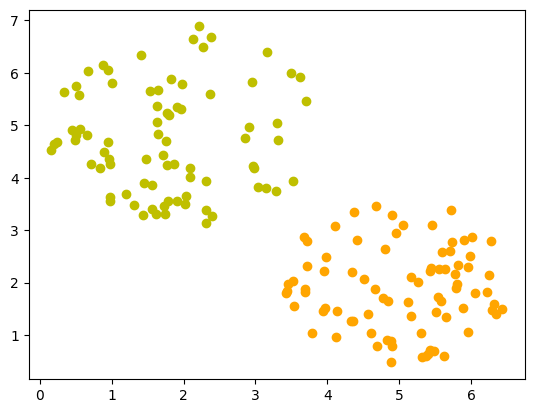

In [17]:
"""
Both on the learning and on the test data, we have only correct values, i.e. our network was capable of learning
automatically and successfully!
We visualize the decision boundary with the following program:
"""
X = np.arange(0, 7)
fig, ax = plt.subplots()

lemons = [train_data[i] for i in range(len(train_data)) if train_labels[i] == 1]
# print(lemons)
lemons_x, lemons_y = zip(*lemons)
oranges = [train_data[i] for i in range(len(train_data)) if train_labels[i] == 0]
# print(oranges)
oranges_x, oranges_y = zip(*oranges)

ax.scatter(oranges_x, oranges_y, c="orange")
ax.scatter(lemons_x, lemons_y, c="y")

In [19]:
w1 = p.weights[0]        # now weights are adjusted
w2 = p.weights[1]
m = -w1 / w2
m

0.8275382754698359

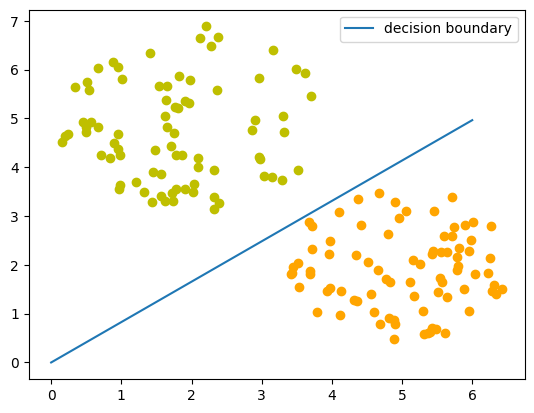

In [24]:
X = np.arange(0, 7)
fig, ax = plt.subplots()

lemons = [train_data[i] for i in range(len(train_data)) if train_labels[i] == 1]
# print(lemons)
lemons_x, lemons_y = zip(*lemons)
oranges = [train_data[i] for i in range(len(train_data)) if train_labels[i] == 0]
# print(oranges)
oranges_x, oranges_y = zip(*oranges)

ax.scatter(oranges_x, oranges_y, c="orange")
ax.scatter(lemons_x, lemons_y, c="y")

w1 = p.weights[0]        # now weights are adjusted
w2 = p.weights[1]
m = -w1 / w2

ax.plot(X, m * X, label="decision boundary")
ax.legend()
plt.show()

In [25]:
print(p.weights)

[-1.45073685  1.75307522]
